In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('sales.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   order_id  149116 non-null  int64  
 1   date      149116 non-null  object 
 2   store     149116 non-null  object 
 3   product   149116 non-null  object 
 4   quantity  149116 non-null  int64  
 5   sales     149116 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 6.8+ MB


In [7]:
df_Astoria = df[df['store']=='Astoria']
df_Astoria.head()

,order_id,date,store,product,quantity,sales
105,106,01/01/2023,Astoria,Drip coffee,1,2.00
106,107,01/01/2023,Astoria,Barista Espresso,1,3.75
107,108,01/01/2023,Astoria,Pastry,1,3.50
111,112,01/01/2023,Astoria,Hot chocolate,1,4.50
113,114,01/01/2023,Astoria,Hot chocolate,1,4.50


In [8]:
df_Astoria.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50599 entries, 105 to 149108
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   order_id  50599 non-null  int64  
 1   date      50599 non-null  object 
 2   store     50599 non-null  object 
 3   product   50599 non-null  object 
 4   quantity  50599 non-null  int64  
 5   sales     50599 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 2.7+ MB


In [9]:
df_Astoria.shape

(50599, 6)

In [10]:
df_Astoria.isnull().sum()

order_id    0
date        0
store       0
product     0
quantity    0
sales       0
dtype: int64

In [11]:
df_Astoria.describe()

,order_id,quantity,sales
count,50599.000000,50599.000000,50599.000000
mean,75046.022431,1.403012,4.589891
std,43264.198245,0.490508,2.877599
min,106.000000,1.000000,0.800000
25%,37270.500000,1.000000,3.000000
50%,75240.000000,1.000000,3.750000
75%,112307.500000,2.000000,6.000000
max,149449.000000,2.000000,45.000000


In [12]:
df_Astoria.quantity.describe()

count    50599.000000
mean         1.403012
std          0.490508
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          2.000000
Name: quantity, dtype: float64

In [13]:
df_Astoria.skew(numeric_only=True)

order_id   -0.002343
quantity    0.395475
sales       4.989976
dtype: float64

In [14]:
df_Astoria.kurtosis(numeric_only=True)

order_id    -1.198795
quantity    -1.843672
sales       48.007990
dtype: float64

array([[<Axes: title={'center': 'order_id'}>,
        <Axes: title={'center': 'quantity'}>],
       [<Axes: title={'center': 'sales'}>, <Axes: >]], dtype=object)

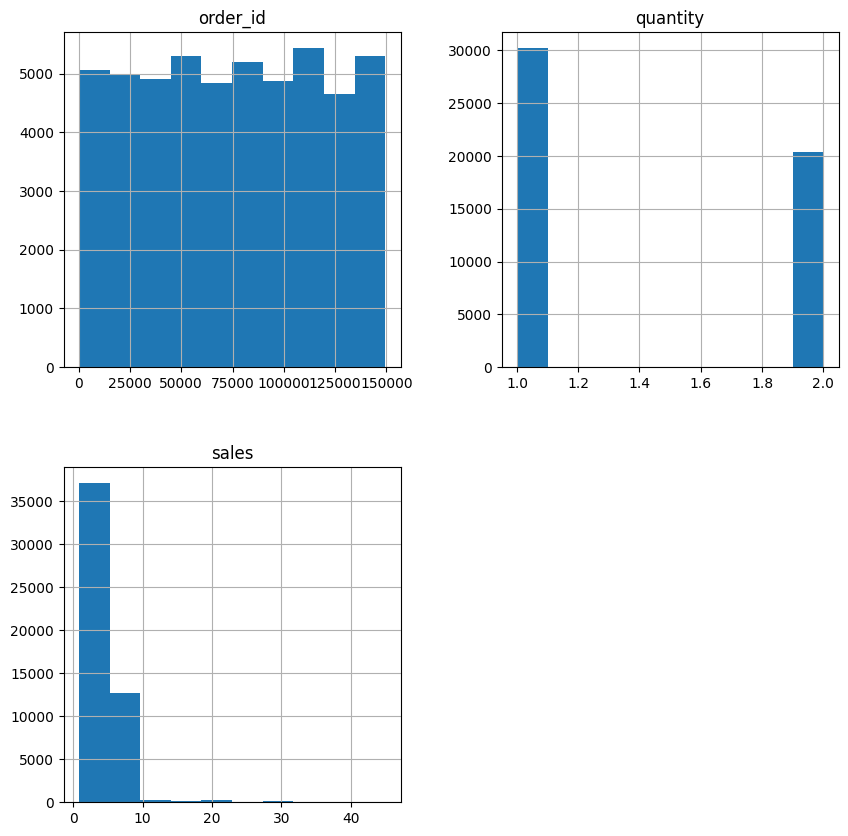

In [15]:
features = ['order_id', 'quantity', 'sales'] # create a list of all numerical features
df_Astoria[features].hist(figsize=(10,10))

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

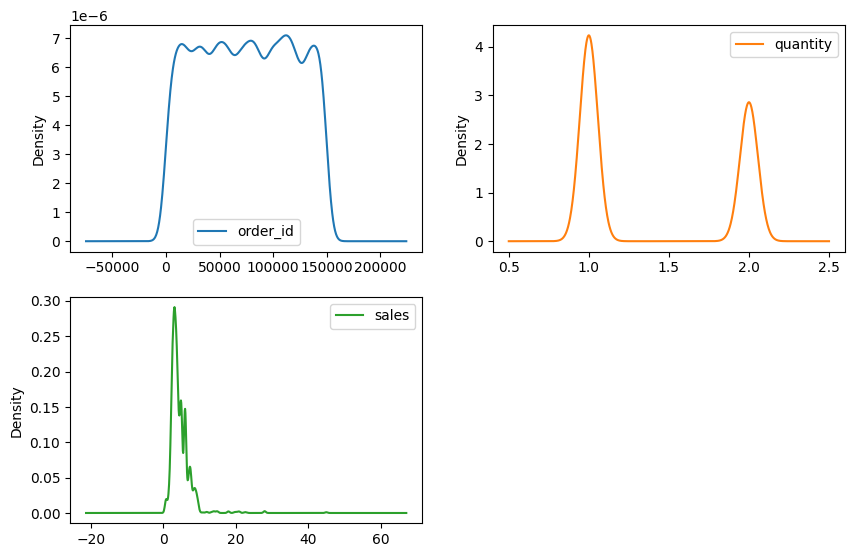

In [16]:
df_Astoria[features].plot(kind='density', subplots=True, layout=(3, 2), sharex=False, figsize=(10, 10))

<Axes: xlabel='order_id'>

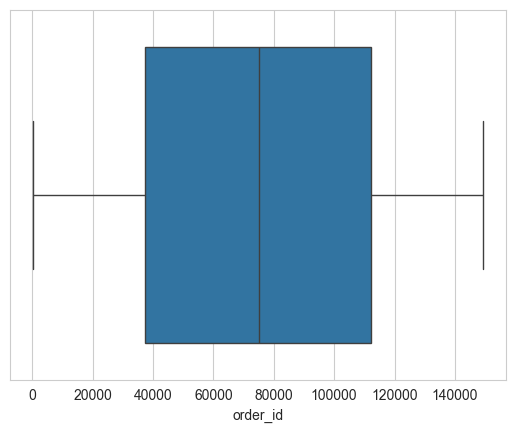

In [29]:
sns.boxplot(x='order_id', data=df_Astoria)
# sns.boxplot(data=df_Astoria[["quantity", "sales"]])
# sns.boxplot(data=df_Astoria[["order_id", "quantity", "sales"]])


<Axes: xlabel='order_id'>

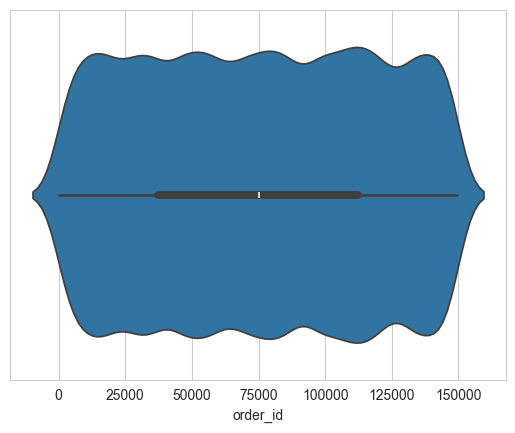

In [32]:
sns.violinplot(x='order_id', data=df_Astoria)
# sns.violinplot(data=df_Astoria[["quantity", "sales"]])
# sns.violinplot(data=df_Astoria[["order_id", "quantity", "sales"]])

Text(0.5, 1.0, 'Distribution of Sales')

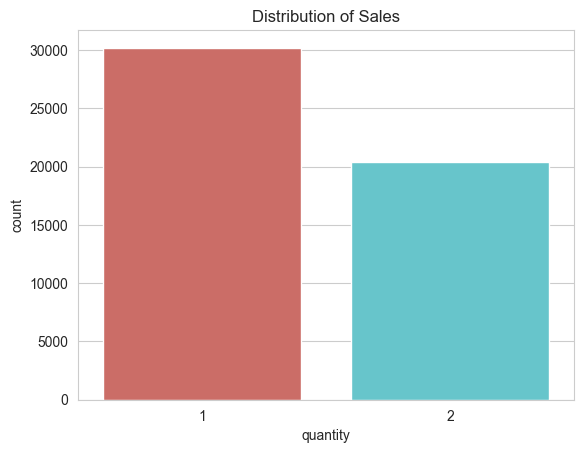

In [ ]:
sns.countplot(x = 'quantity', data = df_Astoria, palette="hls")
plt.title("Distribution of Quantity")

In [20]:
df_Astoria.corr(numeric_only=True)

,order_id,quantity,sales
order_id,1.000000,0.005161,-0.000355
quantity,0.005161,1.000000,0.396900
sales,-0.000355,0.396900,1.000000


Text(0.5, 1.0, 'Astoria')

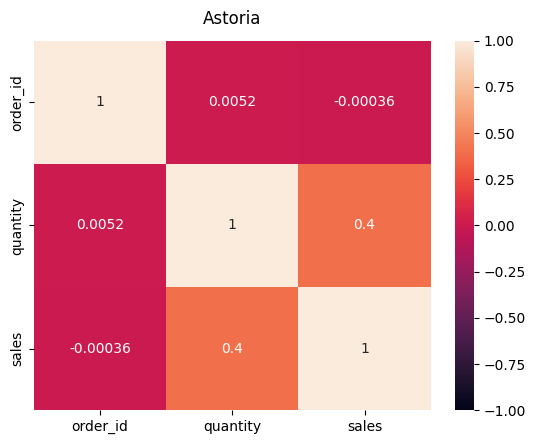

In [21]:
heatmap = sns.heatmap(df_Astoria.corr(numeric_only=True), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Astoria', fontdict={'fontsize':12}, pad=12)

<Axes: xlabel='order_id', ylabel='sales'>

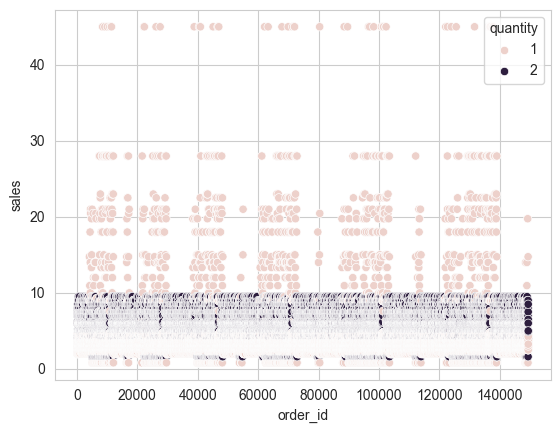

In [36]:
sns.scatterplot(x='order_id',y='sales',hue='quantity', data=df_Astoria)

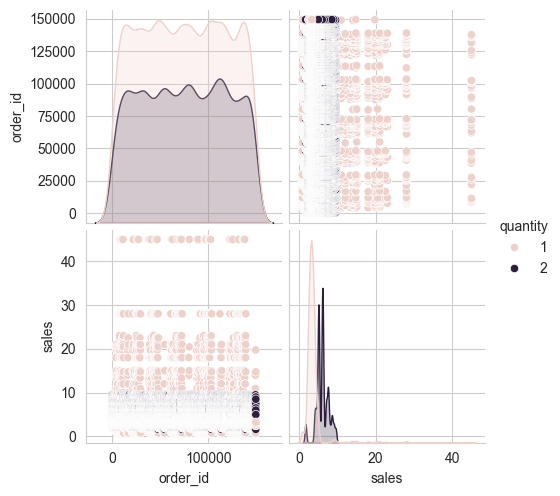

In [23]:
sns.set_style("whitegrid")
sns.pairplot(df_Astoria, hue="quantity")
plt.show()

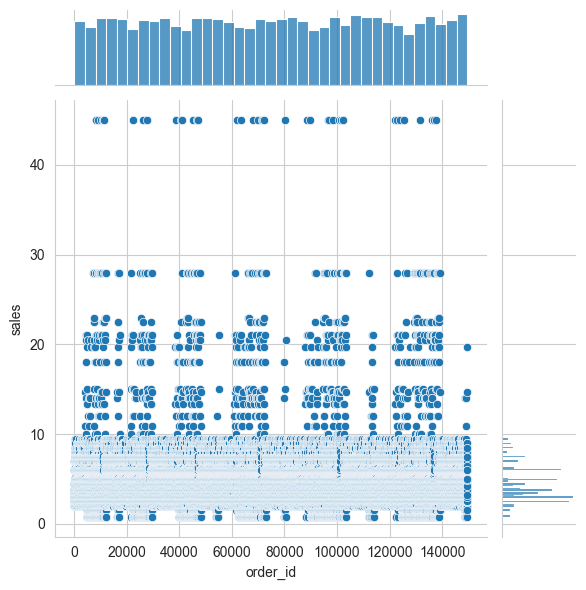

In [37]:
sns.jointplot(x = 'order_id', y = 'sales', data = df_Astoria)

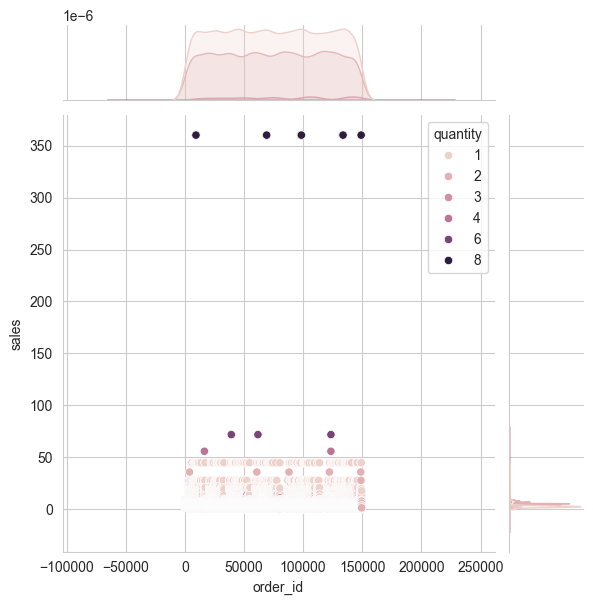

In [25]:
sns.jointplot(x = 'order_id', y = 'sales', data = df, hue='quantity')

<Axes: xlabel='order_id', ylabel='sales'>

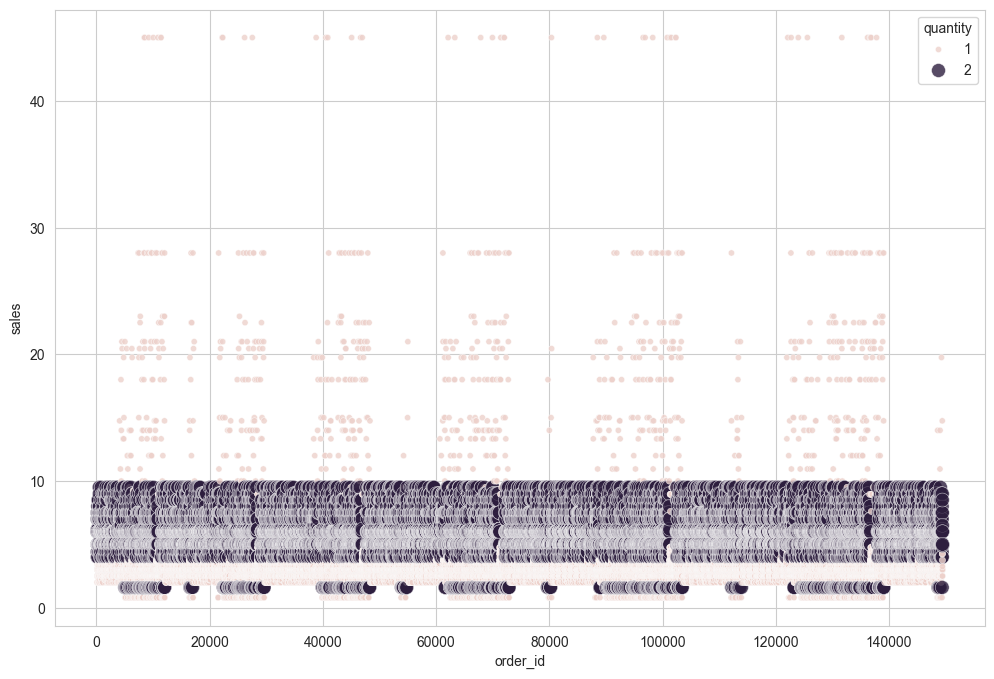

In [26]:
plt.figure(figsize=(12,8))
sns.scatterplot(x="order_id", 
                y="sales",
                size="quantity",
                sizes=(20,100),
                alpha=0.8,
                hue="quantity",
                data=df_Astoria)

Conclusion

1. Data Description
- This analysis uses sources taken from the sales.csv file with a total of 149,116 rows of data. The data structure I took has 6 structures, namely ‘order_id’, ‘date’, ‘store’, ‘product’, ‘quantity’, ‘sales’. In this implementation, I was given the task of analyzing only the “Astoria” store section.

2. Astoria Branch Analysis
- From the total available data, there were 50,599 transactions from the Astoria store with very clean data quality because there were no missing values in all columns. Based on sales statistics, the average transaction value at this branch is around 4.59, with an average purchase volume of 1.4 items per transaction and a maximum of 2 items per order. In addition, the sales price range at this store is quite varied, ranging from a low of 0.8 to a high of 45.0.

3. Distribution Characteristics (Advanced Statistics)
- Skewness: The skewness value for the ‘sales’ column is 4.99, which indicates that the sales data distribution is highly skewed to the right (positively skewed). This means that most transactions are of small value, but there are a few transactions with very large values.
- Kurtosis: The kurtosis value in the ‘sales’ column is very high, at 48.01. This indicates the presence of significant outliers or transactions with values far above the normal average.

4. Visualization
- This notebook has prepared a visualization framework using the ‘seaborn’ and ‘matplotlib’ libraries to view the distribution of ‘order_id’, ‘quantity’, and ‘sales’ graphically to facilitate understanding of data patterns.

The main objectives of this exercise are:
1. Understanding the Sales Characteristics of Specific Branches:
- This analysis is conducted to gain an in-depth understanding of Astoria store performance. By separating Astoria's data from the total 149,116 rows of national data, you aim to see the unique transaction profile at that branch, from the average purchase value to the volume of goods sold.

2. Ensuring Data Quality and Integrity:
- The process of checking missing values aims to ensure that future business decisions are based on clean and complete data. This is important to avoid bias or misinterpretation due to missing data.

3. Identifying Transaction Patterns and Anomalies:
- Calculating skewness and kurtosis values (especially the very high kurtosis value of 48.01) is done to detect the presence of outliers or abnormal transactions. This helps management understand whether there are large “bulk” transactions that are rare but have a significant impact on revenue.

4. Optimizing Stock and Inventory Strategies:
- Knowing that the average customer only purchases 1 to 2 items per transaction, the company can optimize store layout and stock management to be more efficient in serving this type of retail shopping pattern.

5. Data Visualization for Decision Making:
- Creating graphs (such as countplots) aims to convert raw numbers into visual information that is easily understood by management, thereby facilitating the process of evaluating weekly or monthly performance at the Astoria branch.